## Evolution of flow front speeds for jet-driven particle experiments

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functions import apply_filters
from scipy.ndimage import gaussian_filter1d

# Use given style and color maps
from colors import colors7 as colors

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
folder = "../../data/datafiles"

/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_48531/772977013.py:43: RuntimeWarning: divide by zero encountered in log10
  np.log10(times / t0),
/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_48531/772977013.py:44: RuntimeWarning: divide by zero encountered in log10
  np.log10(fronts / l0),
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_48531/772977013.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


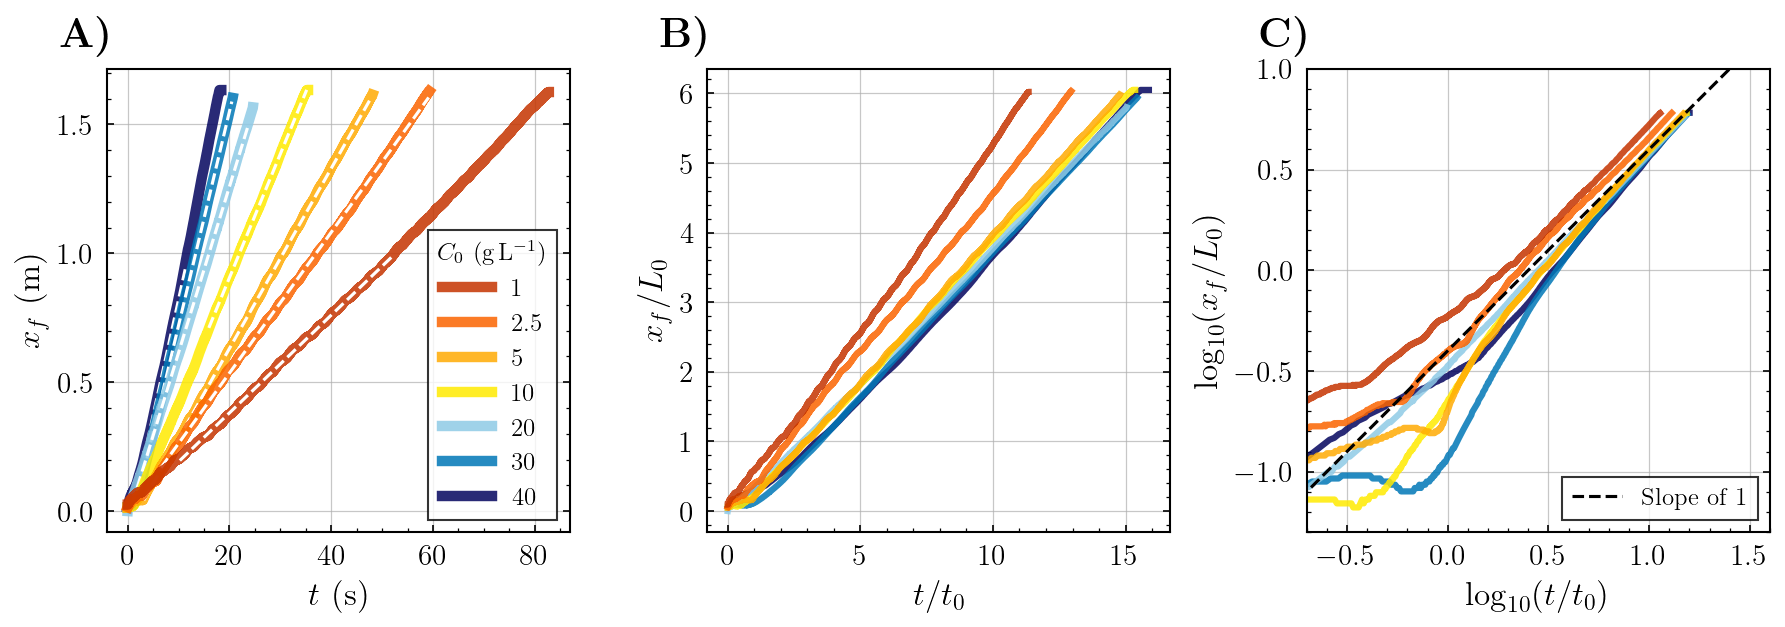

In [2]:
# ============== set up plot ==============
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
fig.get_layout_engine().set(wspace=0.2)

# ---- Load and filter experiments ----
exps_to_plot = (
    apply_filters(
        metadata,
        {"cont": ["none", "stop"], "mixing": "stagnation high Q", "type": "part"},
    )
    .sort_values(by="rho")
    .reset_index(drop=True)
)

# ---- Plot each experiment ----
for _, row in exps_to_plot.iloc[::-1].iterrows():

    c = colors[int(row.exp_code[2]) - 1]

    data = np.load(f"{folder}/{row.exp_code}.npy", allow_pickle=True).item()
    times = np.abs(data["time_s"])
    fronts = np.abs(data["front_m"])

    t0 = l0 / row.u_0

    x_smooth = gaussian_filter1d(fronts, sigma=3)
    v = np.gradient(x_smooth, times)
    a_smooth = gaussian_filter1d(np.gradient(v, times), sigma=3)

    linear_mask = (a_smooth > -a_thresh) & (a_smooth < a_thresh)
    idx = np.where(linear_mask)[0]
    segments = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    longest = max(segments, key=len)

    t_seg = times[longest]
    x_seg = fronts[longest]
    u_c, intercept = np.polyfit(t_seg, x_seg, 1)

    ax[0].plot(times, fronts, color=c, linewidth=5, alpha=0.85, label=f"{row.C0:.2g}")
    ax[0].plot(t_seg, u_c * t_seg + intercept, "w--")
    ax[1].plot(times / t0, fronts / l0, color=c, linewidth=3, alpha=0.85)
    ax[2].plot(
        np.log10(times / t0),
        np.log10(fronts / l0),
        color=c,
        linewidth=3,
        alpha=0.85,
    )

# ============== axes formatting ==============
ax[0].set_xlabel("$t$ (s)")
ax[0].set_ylabel("$x_f$ (m)")
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(
    handles[::-1], labels[::-1], title="$C_0$ (g\\,L$^{-1}$)", loc="lower right"
)

ax[1].set_xlabel("$t/t_0$")
ax[1].set_ylabel("$x_f/L_0$")

ax[2].set_xlabel("$\\log_{10}(t/t_0)$")
ax[2].set_ylabel("$\\log_{10}(x_f/L_0)$")
ax[2].set_xlim([-0.6, 1.5])
ax[2].set_ylim([-1.3, 1])
ax[2].set_aspect("equal")
ax[2].plot(
    np.array([-2, -1, 0, 1, 2, 3]),
    np.array([-2, -1, 0, 1, 2, 3]) - 0.4,
    "k--",
    label="Slope of 1",
)
ax[2].legend(loc="lower right")

for axis, label in zip(ax, ["\\textbf{A)}", "\\textbf{B)}", "\\textbf{C)}"]):
    axis.annotate(
        label, xy=(-0.1, 1.05), xycoords="axes fraction", fontsize=20, fontweight="bold"
    )
    axis.set_box_aspect(1)

plt.tight_layout()
plt.savefig(
    "../figures/figure_9.pdf", format="pdf", bbox_inches="tight", facecolor="white"
)
plt.show()